In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [6]:
# Télécharger population si pas déjà présent
if not os.path.exists("data/raw/population_communes.xlsx"):
    from src.fetch_population import download_population
    download_population()

# Télécharger élections si pas déjà présent
if not os.path.exists("data/raw/elections_legislatives.xlsx"):
    from src.fetch_elections import download_elections
    download_elections()


In [7]:
# Charger population
df_pop = pd.read_excel("data/raw/population_communes.xlsx")

# Charger élections
df_ele = pd.read_excel("data/raw/elections_legislatives.xlsx")

# Vérifier les premières lignes
print("Population :")
display(df_pop.head())

print("Élections :")
display(df_ele.head())



Population :


,objectid,reg,dep,cv,codgeo,libgeo,p13_pop,p14_pop,p15_pop,p16_pop,p17_pop,p18_pop,p19_pop,p20_pop,p21_pop
0,115658,52,85,8502,85062,Châteauneuf,968.0,993.0,1013.0,1027.0,1056,1085.0,1114.0,1118.0,1134.0
1,115659,26,58,5808,58300,Urzy,1839.0,1835.0,1828.0,1802.0,1775,1749.0,1746.0,1747.0,1742.0
2,115660,43,70,7012,70137,Chassey-lès-Montbozon,218.0,217.0,216.0,215.0,217,215.0,215.0,220.0,225.0
3,115661,21,51,5123,51649,Vitry-le-François,13174.0,13144.0,12805.0,12552.0,12133,11743.0,11376.0,11458.0,11454.0
4,115662,11,78,7811,78638,Vaux-sur-Seine,4749.0,4715.0,4788.0,4857.0,4927,4929.0,5010.0,5020.0,5083.0


Élections :


,Code du département,Libellé du département,Code de la circonscription,Libellé de la circonscription,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,...,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44
0,01,Ain,1,1ère circonscription,16,Arbigny,Complet,327,172,52.60,...,31.50,70.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01,Ain,1,1ère circonscription,24,Attignat,Complet,2455,1302,53.03,...,30.18,67.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01,Ain,1,1ère circonscription,29,Beaupont,Complet,446,239,53.59,...,28.70,65.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01,Ain,1,1ère circonscription,38,Bény,Complet,604,317,52.48,...,27.65,60.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01,Ain,1,1ère circonscription,40,Béréziat,Complet,362,196,54.14,...,30.11,67.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
colonnes_utiles = [
    'Code de la commune', 'Libellé de la commune',
    'Code du département', 'Libellé du département',
    'Code de la circonscription', 'Libellé de la circonscription',
    'Exprimés'
]

df_ele_clean = df_ele[colonnes_utiles].copy()
df_ele_clean.columns = [
    'code_commune', 'nom_commune',
    'code_departement', 'nom_departement',
    'code_circonscription', 'nom_circonscription',
    'voix'
]


In [22]:
df_pop_clean = df_pop[['objectid', 'p13_pop']].copy()  # exemple colonne population
df_pop_clean.columns = ['code_commune', 'population']


In [23]:
df_merged = df_ele_clean.merge(df_pop_clean, on='code_commune', how='left')
df_merged.head()


,code_commune,nom_commune,code_departement,nom_departement,code_circonscription,nom_circonscription,voix,population
0,16,Arbigny,01,Ain,1,1ère circonscription,146,NaN
1,24,Attignat,01,Ain,1,1ère circonscription,1100,NaN
2,29,Beaupont,01,Ain,1,1ère circonscription,195,NaN
3,38,Bény,01,Ain,1,1ère circonscription,275,NaN
4,40,Béréziat,01,Ain,1,1ère circonscription,162,NaN


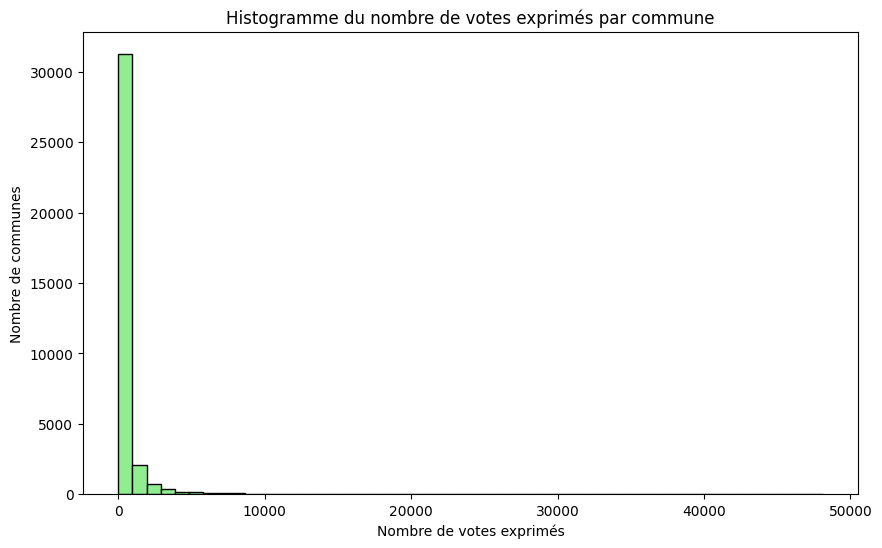

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1000x600 with 1 Axes>

In [24]:
# Histogramme des voix
plt.figure(figsize=(10,6))
plt.hist(df_merged['voix'], bins=50, color='lightgreen', edgecolor='black')
plt.xlabel("Nombre de votes exprimés")
plt.ylabel("Nombre de communes")
plt.title("Histogramme du nombre de votes exprimés par commune")
plt.show()

# Scatter population ↔ votes
plt.figure(figsize=(10,6))
plt.scatter(df_merged['population'], df_merged['voix'], alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Population de la commune (log)")
plt.ylabel("Nombre de votes exprimés (log)")
plt.title("Relation population ↔ votes exprimés")
plt.show()
